The method does not utilize propagation of gradients or any maximum activation locations which
makes it less prone to classification errors. EigenCAM is based on assumption that hierarchical representation of the
features during the propagation process stay the same in direction of the principal components that could be learned
as an explanation purging redundant dependencies

In [1]:
import sys
from pathlib import Path
import torch 

sys.path.append('/Data_large/marine/PythonProjects/MMDET/notebooks/Tools')
sys.path.append('/Data_large/marine/PythonProjects/MMDET/MyConfigs/custom_components')
sys.path.append('/Data_large/marine/PythonProjects/MMDET/MyConfigs')


from mmdet.apis import init_detector, inference_detector
from mmengine.config import Config
from mmengine.runner import load_checkpoint
from mmcv.transforms import Compose

from cam import EigenCAM
import rasterio as rio 
import numpy as np

def estimate_vmin_vmax(cam, percentiles=[5, 95]):
    """
    Estimates vmin and vmax values for the heatmap.

    Parameters:
    - cam (numpy.ndarray): The heatmap.

    Returns:
    - tuple: A tuple containing the vmin and vmax values.
    """
    vmin = np.percentile(cam, percentiles[0])
    vmax = np.percentile(cam, percentiles[1])
    return vmin, vmax

# Required by loader
def read_tif(file_path, band_indices):
    """
    Reads specified bands from a TIFF file.

    Parameters:
    - file_path (str): Path to the .tif file.
    - band_indices (list of int): Indices of the bands to read.

    Returns:
    - numpy.ndarray: A numpy array containing the stacked band data.
    """
    data = []
    with rio.open(file_path) as src:
        for index in band_indices:
            data.append(src.read(index))
    stacked_data = np.stack(data, axis=0)
    return np.transpose(stacked_data, (1, 2, 0))

DATA_PATH_VEN = '/Data_large/marine/Datasets/VENuS/ds_L0/perfect'
DATA_PATH_SEN = '/Data_large/marine/Datasets/VDS2Raw/imgs'

TIFF_VEN = list(Path(DATA_PATH_VEN).rglob('*.tif'))
TIFF_SEN = list(Path(DATA_PATH_SEN).rglob('*.tif'))


# Specify the path to model config and checkpoint file
config_file = '/Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Single/perfect_b5/42_BS_3_LR_0.0009_ME_30_OPT_SGD/vfnet_r18.py'
checkpoint_file = '/Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Single/perfect_b5/42_BS_3_LR_0.0009_ME_30_OPT_SGD/epoch_30.pth'

# build the model from a config file and a checkpoint file
DetModel = init_detector(config_file, checkpoint_file, device='cuda:0')

Loads checkpoint by local backend from path: /Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Single/perfect_b5/42_BS_3_LR_0.0009_ME_30_OPT_SGD/epoch_30.pth


In [ ]:
# from LoaderUnreg import SelBandLoader
# from PreProcessorUnreg import MyPrePro
# from mmdet.models.data_preprocessors import DetDataPreprocessor

# BAND = 5

# ########## TRANSFORMS ##########
# loader = SelBandLoader(
#             to_float32 = False,
#             bands_list = [BAND],
#             ignore_empty = False,
#             backend_args = None
#             )

# IMG_SIZE = 2048
# resizer = Resize(scale=(IMG_SIZE, IMG_SIZE), keep_ratio=False)
# ToTensor = ImageToTensor(keys=['img'])

# MEANS=[158.69588,124.42161,109.27108,105.380424,88.40926,98.93067,88.819916,94.20678,103.540764,111.64337,122.92817,79.31501]
# STD=[34.95446,46.282494,56.252197,55.741932,64.54027,59.59095,69.65824,68.40028,77.930405,103.4634,105.30468,65.8369]
# M, S = MEANS[BAND-1], STD[BAND-1]


# prepro = MyPrePro(mean = [M], pad_size_divisor=1, std=[S])


# ################################
# img_path = TIFF_VEN[0]
# print(img_path)

# IMG_k = loader.transform(results={'img_path': img_path})
# IMG_k = resizer(IMG_k)
# IMG_k = ToTensor(IMG_k)
# tensor = IMG_k['img'].to('cuda:0').unsqueeze(0)
# data_ = prepro({'inputs': tensor})
# inputs = data_['inputs']


Specific Selection

In [2]:
tiffSel = [x for x in TIFF_VEN if 'ASH_L0_08805_20190401_MultiLayer_mask_OK' in str(x)][0]
print(tiffSel)

/Data_large/marine/Datasets/VENuS/ds_L0/perfect/ASH_L0_08805_20190401_MultiLayer_mask_OK.tif


In [7]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

cfg = Config.fromfile(config_file)
cfg = cfg.copy()
test_pipeline = cfg.test_dataloader.dataset.pipeline

model = DetModel
checkpoint = checkpoint_file
checkpoint = load_checkpoint(model, checkpoint, map_location='cpu')


checkpoint_meta = checkpoint.get('meta', {})
dataset_meta = checkpoint_meta['dataset_meta']['classes']
model.dataset_meta = dataset_meta

model.to(device)
model.eval()

Idx = 57

test_pipeline = Compose(test_pipeline)
if tiffSel is None:
    data_ = dict(img_path=TIFF_VEN[Idx], img_id=0)
    ORIGINAL_IMG = read_tif(file_path=TIFF_VEN[Idx], band_indices=[5])

else:
    data_ = dict(img_path=tiffSel, img_id=0)
    ORIGINAL_IMG = read_tif(file_path=tiffSel, band_indices=[5])
    

data_ = test_pipeline(data_)
data_['inputs'] = [data_['inputs']]
data_['data_samples'] = [data_['data_samples']]

Loads checkpoint by local backend from path: /Data_large/marine/PythonProjects/MMDET/checkpoints/VENuS/Single/perfect_b5/42_BS_3_LR_0.0009_ME_30_OPT_SGD/epoch_30.pth


In [8]:
preprocessed = model.data_preprocessor(data_, False)

inputs = preprocessed['inputs'][0]
img_size = (inputs.size()[-2], inputs.size()[-1])

In [ ]:
# import matplotlib.pyplot as plt
# img = preprocessed['inputs'][0].cpu().numpy().transpose(1,2,0)

# plt.figure(figsize=(10,10))
# plt.imshow(img, vmin=img.mean()-img.std(), vmax=img.mean()+img.std(), cmap='gray')
# plt.axis(False)
# plt.show()

#### Inference:

In [9]:
from mmdet.registry import VISUALIZERS

# forward the model
with torch.no_grad():
    results = model.test_step(data_)[0]

visualizer = VISUALIZERS.build(model.cfg.visualizer)

visualizer.dataset_meta = model.dataset_meta

visualizer.dataset_meta = dict(
            classes=('Vessel', ), palette=[
                (
                    220,
                    20,
                    60,
                ),
            ])

visualizer.dpi = 100

visualizer.add_datasample(
name='result',
image=ORIGINAL_IMG,
data_sample=results,
draw_gt=False,
pred_score_thr=0.7,
show=False)

/home/vessel/anaconda3/envs/openmmlab/lib/python3.8/site-packages/mmengine/utils/manager.py:113: UserWarning: <class 'mmdet.visualization.local_visualizer.DetLocalVisualizer'> instance named of visualizer has been created, the method `get_instance` should not accept any other arguments
  warnings.warn(


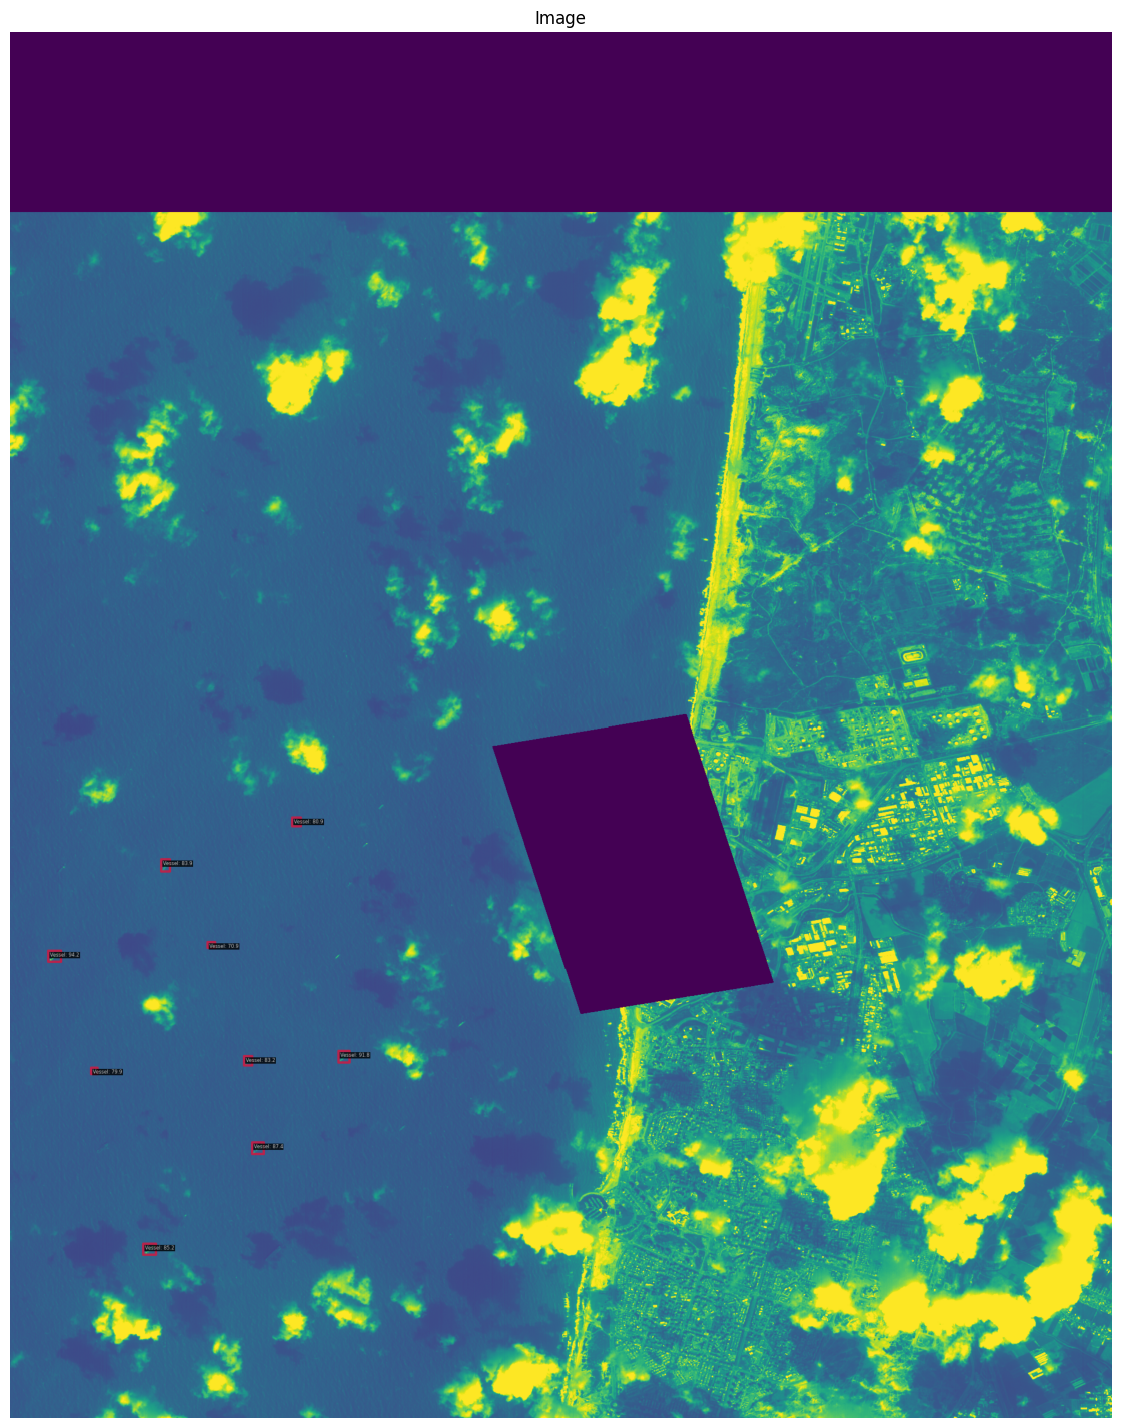

In [10]:
import matplotlib.pyplot as plt
# import plotly.graph_objects as go
# fig = go.Figure(data=go.Image(z=img))
# fig.update_layout(width=800, height=800, title='Image')
# fig.show()

img = visualizer.get_image()

plt.figure(figsize=(18, 18))
plt.imshow(img)
plt.title('Image')
plt.axis('off')
plt.show()

#### Eigen-CAM

Back-Testing encoder

In [ ]:
# encoder = DetModel.backbone
# Neck = DetModel.neck

# encoder.eval()
# Neck.eval()
# x = encoder(inputs.unsqueeze(0).to('cuda:0'))
# out_features = Neck(x)
# for item in out_features:
#     print(item.size())

Notice that we're taking torch.abs(value) on the activations.

This is one way object detection differs quite a lot from the usual classification networks that have ReLU non linearities. The FPN activations are un-bounded and can have negative values as well.

#### Collate all the activations:

In [ ]:
# activations = []
# target_size = (out_features[0].shape[2], out_features[0].shape[3])
# for fmap in out_features:
#     activations.append(torch.nn.functional.interpolate(torch.abs(fmap), target_size, mode='bilinear'))

# activations = torch.cat(activations, axis=1)

### Prompt the Eigen-CAM

In [ ]:
# import cv2

# # activations = torch.abs(out_features[0])
# activations = out_features[-2]
# principal_comp = 0


# for principal_comp in range(0, 5):
#     # Centering before the SVD seems to be important here,
#     # Otherwise the image returned is negative
#     reshaped_activations = activations - activations.mean(axis=0)

#     _, _, vT = torch.linalg.svd(activations, full_matrices=True)
#     v1 = vT[:, :, principal_comp, :][..., None, :]

#     cam = activations @ v1.repeat(1, 1, v1.shape[3], 1)
#     cam = cam.sum(1)
#     cam -= cam.min()
#     cam = cam / cam.max() * 255
#     cam = cam.cpu().detach().numpy().transpose(1, 2, 0).astype(np.uint8)
#     cam = cv2.resize(cam, img_size)


#     import matplotlib.pyplot as plt

#     plt.figure(figsize=(12, 12))
#     plt.subplot(1, 2, 1)
#     img_p = inputs.cpu().numpy().transpose(1,2,0)[1000:1800, 100:800]
#     plt.imshow(img_p, cmap='jet')
#     plt.colorbar(shrink=0.4)


#     plt.subplot(1, 2, 2)
#     cut = cam[1000:1800, 100:800]
#     vmin, vmax = estimate_vmin_vmax(cut, percentiles=[0, 99])
#     plt.imshow(cut, cmap='jet', vmin=vmin, vmax=vmax)
#     plt.colorbar(shrink=0.4)

#     plt.show()

In [37]:
layer_to_visualize = []
for name, module in DetModel.named_modules():
    if 'lateral_convs.' in name:
        if not name.endswith('conv'):
            print(name)
            layer_to_visualize.append(name)

neck.lateral_convs.0
neck.lateral_convs.1
neck.lateral_convs.2


In [38]:
# layer_to_visualize = ['backbone.layer1','backbone.layer2','backbone.layer3','backbone.layer4']
print(len(layer_to_visualize))

3


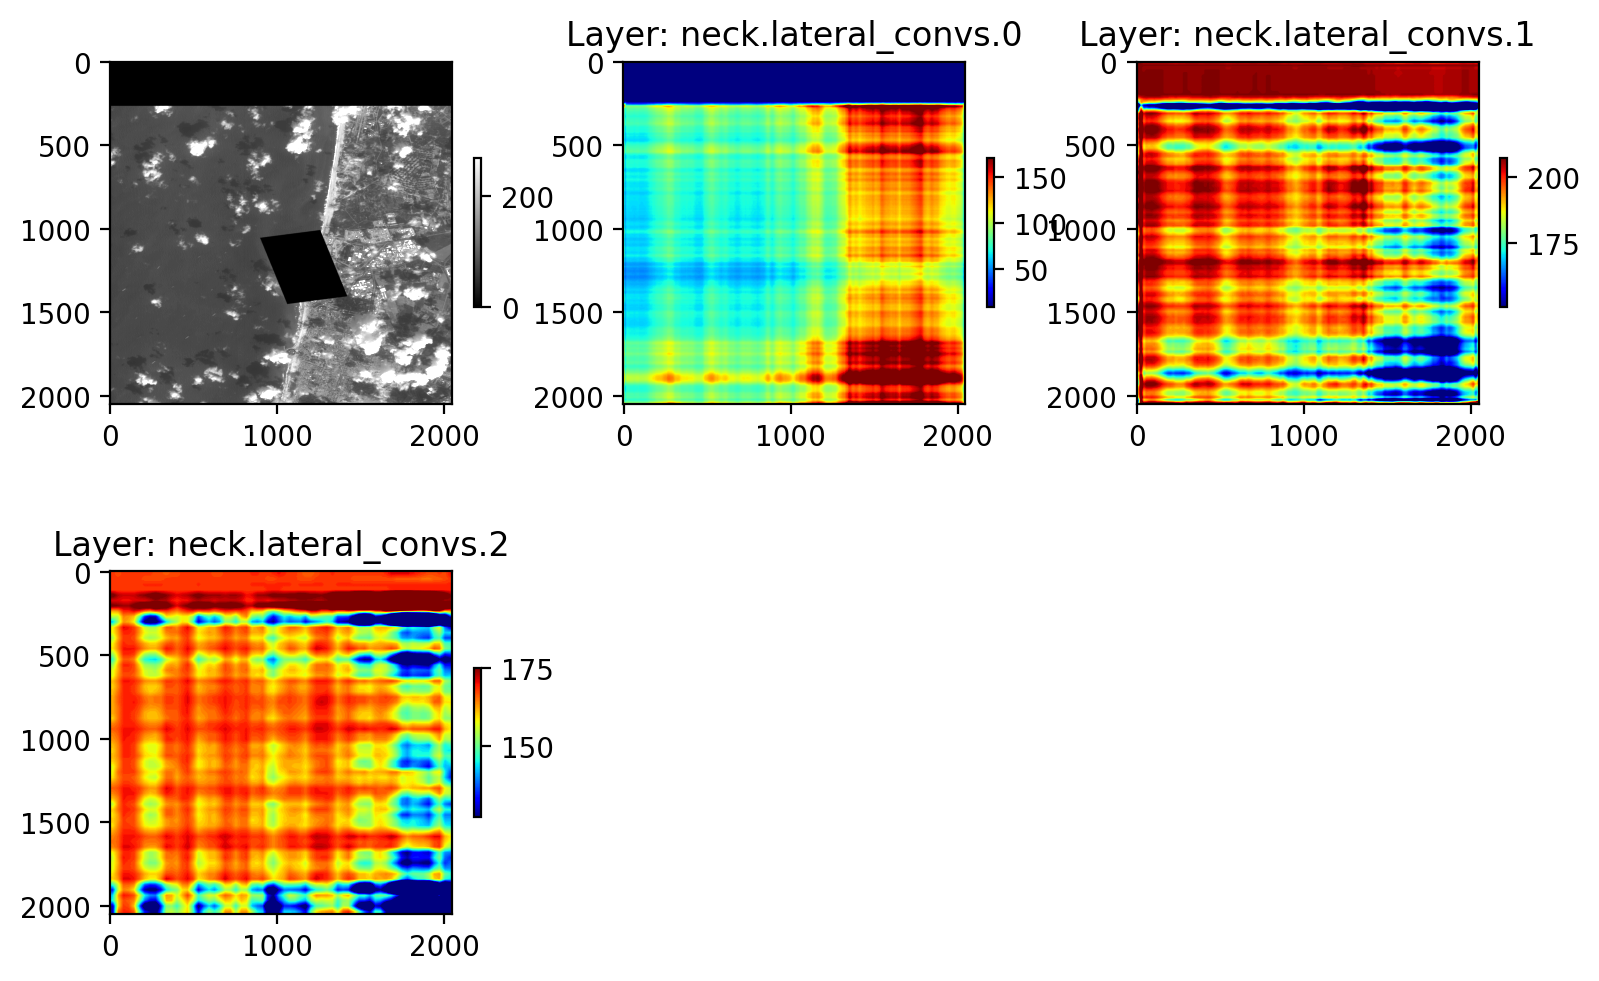

In [40]:
import matplotlib.pyplot as plt
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# forward the model
with torch.no_grad():
    results = model.test_step(data_)[0]


plt.figure(figsize=(16, 16), dpi=200)
plt.subplot(5, 5, 1)
img = data_['inputs'][0].cpu().numpy()
vmin, vmax = estimate_vmin_vmax(img, percentiles=[4, 97])
plt.imshow(img.transpose(1,2,0), cmap='gray', vmin=vmin, vmax=vmax) # transpose to (H, W, C) for plotting
plt.colorbar(shrink=0.35)

windows = [2,3,6,7]

for i, layer_name in enumerate(layer_to_visualize):
    cam_obj = EigenCAM(DetModel, device, None, layer_name)
    toCAM = torch.from_numpy(img.copy())

    cam = cam_obj.get_heatmap(toCAM.float())
    
    plt.subplot(5, 5, windows[i]) # Starting from the second column
    vmin, vmax = estimate_vmin_vmax(cam, percentiles=[4, 97])
    plt.imshow(cam, cmap='jet', vmin=vmin, vmax=vmax)
    plt.title(f'Layer: {layer_name}')
    plt.colorbar(shrink=0.35)

plt.show()

/tmp/ipykernel_1874464/2057782362.py:4: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(4, 4, i + 1)  # Starting from the s


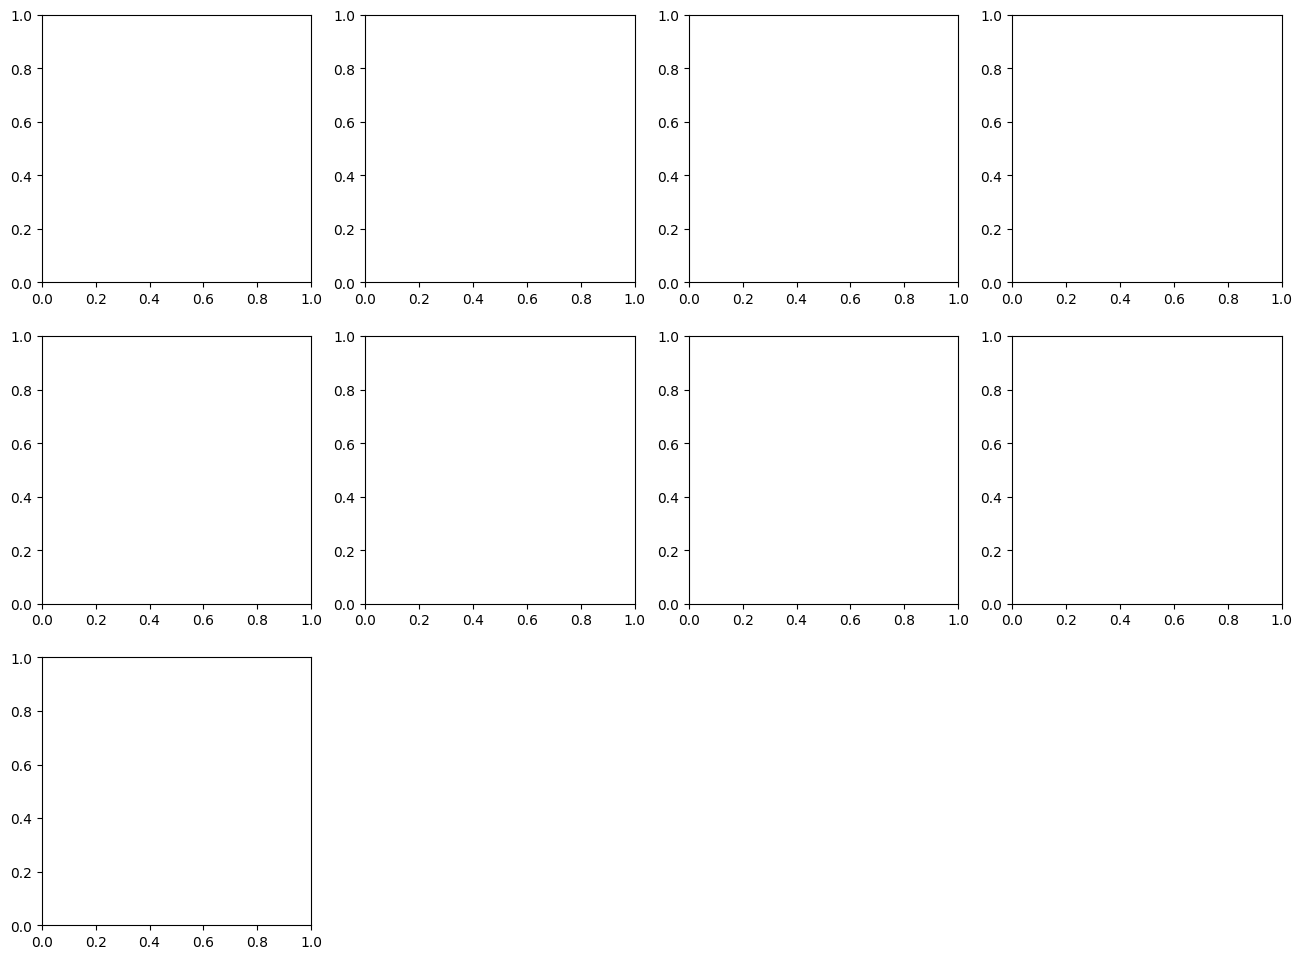

In [33]:
plt.figure(figsize=(16, 16))
plt.subplot(1, 2, 1)

for i in range(9):
    plt.subplot(4, 4, i + 1)  # Starting from the s


In [ ]:
import plotly.graph_objects as go

fig = go.Figure(data=go.Image(z=overlay))
fig.update_layout(width=800, height=800, title='Overlay Image')
fig.show()
